<a href="https://colab.research.google.com/github/vifirsanova/ML-2026-pt-2/blob/main/beginners/2_trees/trees_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Алгоритмы машинного обучения на основе деревьев

**Курс ВШЭ «Машинное обучение» (Фирсанова)**  
Дополнительные материалы: [GitHub-репозиторий курса](https://github.com/vifirsanova/ML-2026-pt-2/)

Иллюстрации брала [отсюда](https://www.geeksforgeeks.org/machine-learning/tree-based-machine-learning-algorithms/)

---

## Принцип работы

1. **Разбиение по признаку** — выбор наиболее информативного признака с помощью критерия Джини или энтропии.
2. **Рекурсивное разбиение** — разделение подмножеств и повтор процесса.
3. **Критерии остановки** — максимальная глубина или минимальное количество выборок.
4. **Прогнозирование** — назначение класса (классификация) или среднего значения (регрессия) в листе.

## 1. Дерево решений (Decision Tree)

Базовый элемент. Разбиение на основе математических правил.

**Критерии разделения (формулы):**

**Примесь Джини** — для узла с долями классов $p_i$:
$$G = 1 - \sum_{i=1}^{C} p_i^2$$
Чем меньше $G$, тем чище узел.

**Энтропия**:
$$H = - \sum_{i=1}^{C} p_i \log_2 p_i$$

**Прирост информации** для разбиения $S$ на $k$ подмножеств:
$$IG(S) = H(S) - \sum_{j=1}^{k} \frac{|S_j|}{|S|} H(S_j)$$

**Визуализация дерева:**

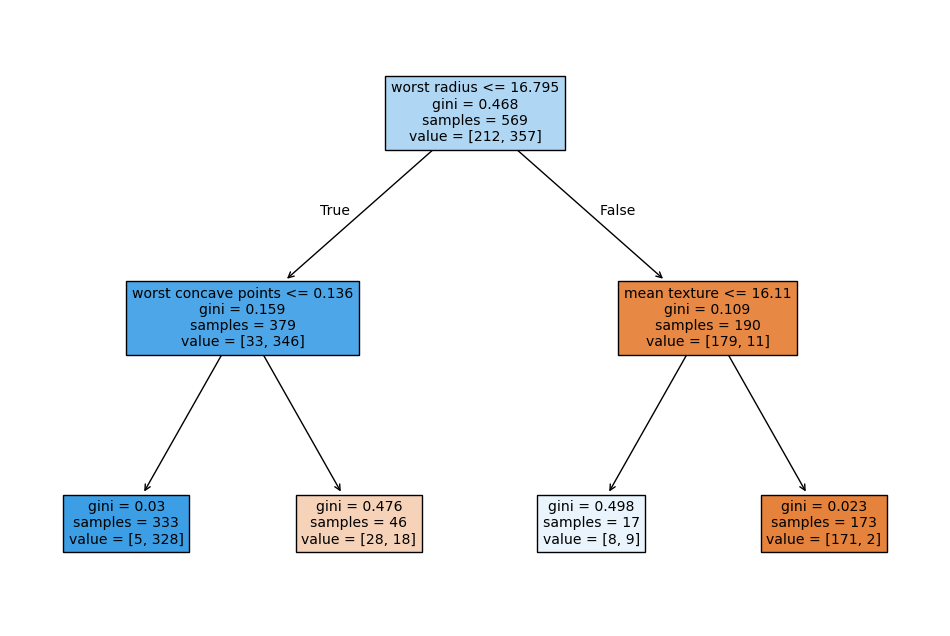

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target

clf = DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=2)
clf.fit(X, y)

plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=data.feature_names, filled=True)
plt.show()

**Вопрос по документации sklearn:**  
Найдите параметр `min_impurity_decrease` в `DecisionTreeClassifier`. Напишите формулу, которая вычисляется, и объясните, как этот параметр влияет на остановку разбиения.

## 2. Случайный лес (Random Forest)

Ансамбль, строящий $M$ деревьев на разных **бутстрэп-выборках** (случайное повторение с возвращением) — этот метод называется **бэггинг** (Bootstrap Aggregating).

**Формула прогноза для классификации:**
$$\hat{y} = \text{mode}\left( \{ h_m(x) \}_{m=1}^{M} \right)$$

**Для регрессии:**
$$\hat{y} = \frac{1}{M} \sum_{m=1}^{M} h_m(x)$$

**Визуализация:**
- Лес из 100 деревьев, каждое обучено на ~63% исходных данных (бутстрэп)
- Каждое дерево случайно выбирает `sqrt(n_features)` признаков на каждом разбиении
- Итоговый прогноз — голосование всех деревьев

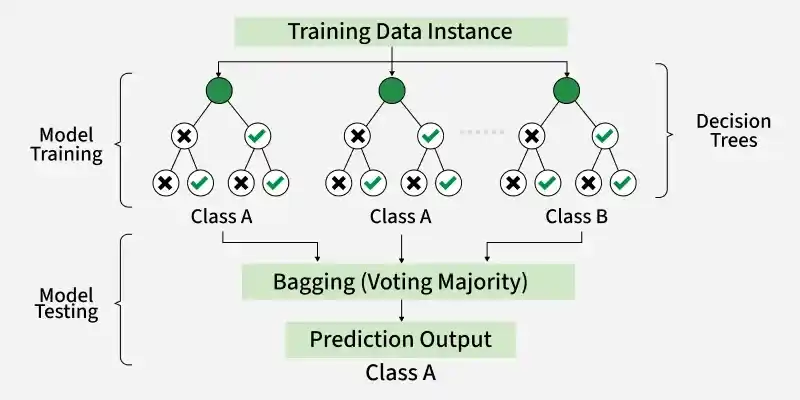

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# n_estimators = количество деревьев в лесу. Чем больше, тем точнее и стабильнее, но дольше обучение. Оптимально от 100 до 500.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
predictions = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.9649122807017544


**Вопрос по документации sklearn:**  
Какой параметр в `RandomForestClassifier` контролирует долю выборки для обучения каждого дерева? Назовите его дефолтное значение.

## 3. Градиентный бустинг (Gradient Boosting)

**Бустинг** — метод, где каждое дерево **корректирует остатки предыдущего** (ошибки). В отличие от бэггинга, здесь деревья обучаются последовательно, а не параллельно.

**Алгоритм:**  
Если предыдущая модель $F_{t-1}(x)$ ошиблась на объекте $x_i$ на величину $y_i - F_{t-1}(x_i)$, то новое дерево $h_t$ обучается предсказывать именно эту ошибку (остаток).

**Обновление модели:**
$$F_t(x) = F_{t-1}(x) + \nu \cdot h_t(x)$$
$\nu$ — скорость обучения (`learning_rate`), $h_t$ обучается на псевдо-остатках:
$$r_i = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F=F_{t-1}}$$

**Визуализация:**
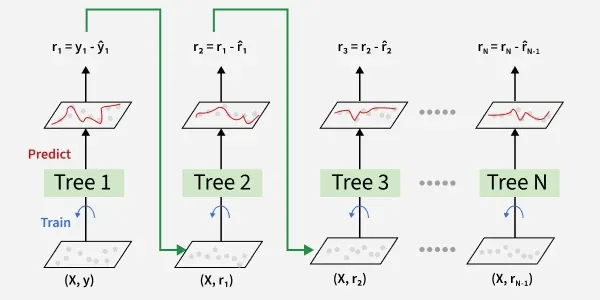

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# n_estimators = количество шагов бустинга (деревьев). Слишком много даст переобучение.
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, gb.predict(X_test)))

**Вопрос по документации sklearn:**  
Параметр `subsample < 1.0` в `GradientBoostingClassifier` делает алгоритм стохастическим. Какой параметр в `RandomForestClassifier` делает нечто похожее?

## 4. XGBoost

**Гессиан** — вторая производная функции потерь. XGBoost использует разложение Тейлора до 2-го порядка (в отличие от классического градиентного бустинга, который использует только 1-ю производную).

**Функция потерь с регуляризацией:**
$$\mathcal{L} = \sum_i L(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$$
$$\Omega(f) = \gamma T + \frac{1}{2} \lambda \|w\|^2 + \alpha |w|$$
($T$ — число листьев, $w$ — веса в листьях).

In [4]:
from xgboost import XGBClassifier

# eval_metric='logloss' — метрика для оценки на валидации. Logloss = логарифмическая функция потерь для бинарной классификации.
model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42,
                      eval_metric='logloss')
model.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.956140350877193


**Вопрос по документации XGBoost:**  
Параметр `gamma` в XGBoost контролирует минимальное снижение функции потерь для создания нового листа. Какой аналог (по смыслу) есть в `GradientBoostingClassifier`? Напишите название параметра и объясните разницу.

## 5. AdaBoost

Адаптивный бустинг: **перевзвешивание объектов** — на каждом шаге веса неправильно классифицированных объектов увеличиваются.

**Алгоритм:**
1. Веса $w_i^{(1)} = 1/N$
2. Для $t = 1 \ldots T$:
   - Обучить классификатор $h_t$ с весами $w^{(t)}$
   - Вычислить ошибку $\epsilon_t$
   - Вес модели: $\alpha_t = \frac{1}{2} \ln\left(\frac{1-\epsilon_t}{\epsilon_t}\right)$
   - Обновить веса объектов: $w_i^{(t+1)} = w_i^{(t)} \cdot \exp(-\alpha_t y_i h_t(x_i))$

In [5]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
model.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.9736842105263158


**Вопрос по документации sklearn:**  
Параметр `algorithm` в `AdaBoostClassifier` может быть `'SAMME'` или `'SAMME.R'`. Чем отличается обновление весов? Какой используется по умолчанию и почему?

## 6. LightGBM

**Гистограммный** — признак дискретизируется в бины (например, все значения `worst radius` от 1 до 20 разбиваются на 256 корзин). Это ускоряет поиск лучшего разбиения с $O(n)$ до $O(бины)$.

**Leaf-wise рост:** растет узел с наибольшим снижением потерь, а не все узлы уровня одновременно.

**Формула снижения потерь для split:**
$$\Delta loss = \frac{ \left( \sum_{i \in L} g_i \right)^2 }{ \sum_{i \in L} h_i + \lambda } + \frac{ \left( \sum_{i \in R} g_i \right)^2 }{ \sum_{i \in R} h_i + \lambda } - \frac{ \left( \sum_{i \in P} g_i \right)^2 }{ \sum_{i \in P} h_i + \lambda }$$
($g_i$ — градиент, $h_i$ — гессиан, $\lambda$ — регуляризация)

In [6]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000359 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


**Вопрос по документации LightGBM:**  
Как параметр `num_leaves` связан с `max_depth` в LightGBM? Почему значение `num_leaves = 255` может привести к переобучению даже при небольшой глубине?

## 7. CatBoost

**Ordered boosting** — метод против **утечки** (data leakage). Утечка — это когда информация о целевом признаке из будущих данных просачивается в обучение. CatBoost этого избегает, обучая каждое дерево на объектах без него.

**Кодирование категорий:**
$$\text{Enc}(x_k) = \frac{ \sum_{j=1}^{n} [x_j = x_k] \cdot y_j + a p }{ \sum_{j=1}^{n} [x_j = x_k] + a }$$
($p$ — априорная вероятность, $a$ — вес априорного значения)



In [8]:
!pip install catboost -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


In [9]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(iterations=100, learning_rate=0.1, random_state=42, verbose=0)
model.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.9649122807017544


**Вопрос по документации CatBoost:**  
Что означает параметр `one_hot_max_size` и когда его следует увеличивать? Как это влияет на обработку категориальных признаков?

## Преимущества и ограничения

**+** интерпретируемость (особенно у одного дерева)  
**+** работа с нелинейностями  
**+** автоматический отбор важных признаков

**–** склонность к переобучению  
**–** нестабильность у одного дерева  
**–** ансамбли сложнее для анализа